Load offer decision layer artifacts

In [1]:
import json

import matplotlib.pyplot as plt
import polars as pl

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
BLUE, ORANGE = "#2a78d6", "#eb6834"

manifest = json.load(open("data/processed/nbo/_manifest.json"))
divergence = json.load(open("data/processed/nbo/_divergence_manifest.json"))

manifest["scoring_date"], manifest["margin_rate"], manifest["contact_cost_multiplier"], manifest["coverage"]["covered_customers"]

('2020-09-16', 0.5, 0.001, 642169)

Coverage

In [2]:
pl.DataFrame([manifest["coverage"]])

covered_customers,total_customers,coverage,in_sample_covered_customers,in_sample_share_of_covered
i64,i64,f64,i64,f64
642169,1371980,0.46806,128040,0.199387


Selected-article concentration

In [3]:
pl.DataFrame([manifest["top_article_concentration"]])

distinct_selected_articles,total_selections,share_of_selections_in_top_10
i64,i64,f64
4876,642169,0.414129


Strategy mix

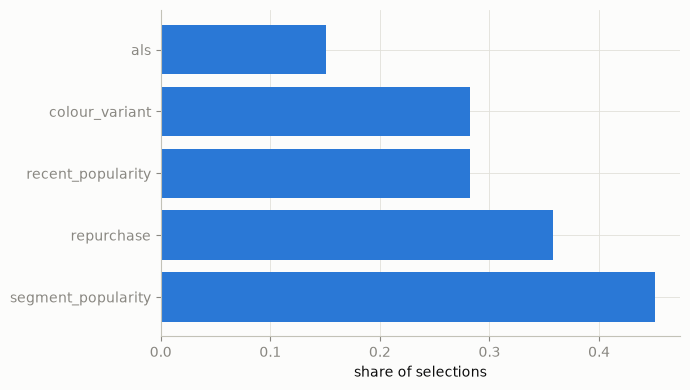

In [4]:
mix = manifest["strategy_mix"]
mix_df = pl.DataFrame({"strategy": list(mix.keys()), "share_of_selections": list(mix.values())}).sort(
    "share_of_selections", descending=True
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(mix_df["strategy"], mix_df["share_of_selections"], color=BLUE)
ax.set_xlabel("share of selections")
fig.tight_layout()

Selected offer vs. ranker top-1

In [5]:
pl.DataFrame([manifest["ranker_top1_divergence"]])

covered_customers,share_differing_from_ranker_top1
i64,f64
642169,0.395843


Divergence decomposition

In [6]:
covered = divergence["covered_customers"]
pl.DataFrame(
    [
        {
            "cause": cause,
            "customers": case["count"],
            "share_of_covered": case["count"] / covered,
            "share_of_diverging": case["share_of_differs"],
            "median_selected_to_top1_price_ratio": case.get("median_selected_to_top1_price_ratio"),
        }
        for cause, case in divergence["cases"].items()
    ]
)

cause,customers,share_of_covered,share_of_diverging,median_selected_to_top1_price_ratio
str,i64,f64,f64,f64
"""a_top1_purchased_recently""",63923,0.099542,0.251469,null
"""b_top1_not_sold_recently""",35,0.000055,0.000138,null
"""c_top1_eligible_but_beaten_on_…",190240,0.296246,0.748393,1.260908


Price distribution: selected offers vs. ranker top-1

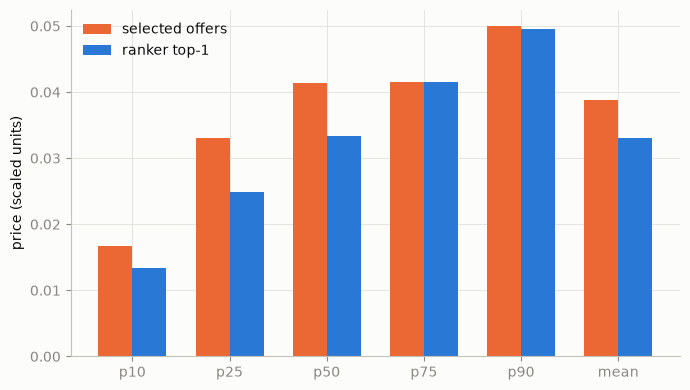

In [7]:
price_dist = manifest["price_distribution_vs_ranker_top1"]
quantiles = ["p10", "p25", "p50", "p75", "p90", "mean"]

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(quantiles))
width = 0.35
ax.bar([i - width / 2 for i in x], [price_dist["selected_offers"][q] for q in quantiles], width, label="selected offers", color=ORANGE)
ax.bar([i + width / 2 for i in x], [price_dist["ranker_top1"][q] for q in quantiles], width, label="ranker top-1", color=BLUE)
ax.set_xticks(list(x))
ax.set_xticklabels(quantiles)
ax.set_ylabel("price (scaled units)")
ax.legend(frameon=False)
fig.tight_layout()

Sensitivity grid: coverage by margin_rate and contact_cost multiplier

In [8]:
grid = pl.DataFrame(manifest["sensitivity_grid"])
pivot = grid.pivot(on="contact_cost_multiplier", index="margin_rate", values="coverage").sort("margin_rate")
pivot

margin_rate,0.0005,0.001,0.002,0.005,0.01,0.02
f64,f64,f64,f64,f64,f64,f64
0.3,0.552032,0.244662,0.091533,0.014239,0.002674,0.000146
0.4,0.634916,0.382287,0.134497,0.027363,0.004859,0.000515
0.5,0.805069,0.46806,0.183802,0.042393,0.008725,0.001259
0.6,0.876709,0.552032,0.244662,0.065509,0.014239,0.002674


Sensitivity grid, plotted against the contact_cost / margin_rate ratio

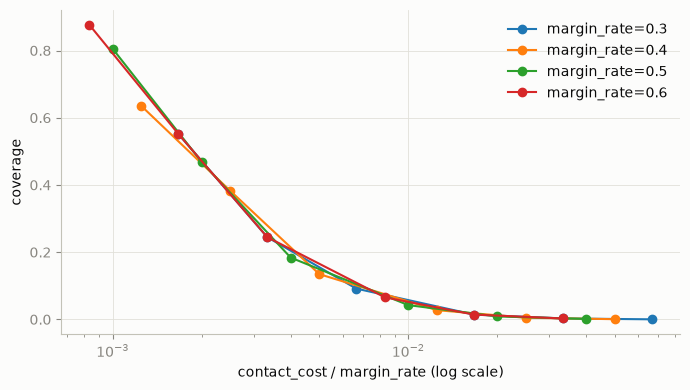

In [9]:
grid_sorted = grid.sort("ratio")

fig, ax = plt.subplots(figsize=(7, 4))
for margin_rate in sorted(grid["margin_rate"].unique()):
    sub = grid_sorted.filter(pl.col("margin_rate") == margin_rate)
    ax.plot(sub["ratio"], sub["coverage"], marker="o", label=f"margin_rate={margin_rate}")
ax.set_xscale("log")
ax.set_xlabel("contact_cost / margin_rate (log scale)")
ax.set_ylabel("coverage")
ax.legend(frameon=False)
fig.tight_layout()

Equal-ratio sensitivity assertion

In [10]:
manifest["sensitivity_equal_ratio_groups_checked"], manifest["sensitivity_equal_ratio_assertion"]

(4,
 "passed, every cell's own contact_cost/margin_rate ratio recomputed to its group's ratio and every group's mapped coverage was identical across members; the underlying argmax-invariance fact is proven separately on synthetic data by tests/test_nbo.py, not re-derived here")